In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mansoordaku/ckdisease")

print("Path to dataset files:", path)

100%|██████████| 9.51k/9.51k [00:00<00:00, 13.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mansoordaku/ckdisease/versions/1


In [2]:
import os
import pandas as pd

# List the contents of the directory
print(f"Contents of the dataset directory: {os.listdir(path)}")

# Assuming the dataset file is named 'kidney_disease.csv'
dataset_file = 'kidney_disease.csv'
full_file_path = os.path.join(path, dataset_file)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(full_file_path)

# Display the first few rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

Contents of the dataset directory: ['kidney_disease.csv']
First 5 rows of the DataFrame:
   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet   pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good   no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good   no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor   no  yes            ckd  
3  ...   32  6700  3.9  yes   no   no  poor  yes  yes            ckd  
4  ...   35  7300  4.6   no   no   no  good   no   no            ckd  

[5 

In [3]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nMissing Values Count:")
print(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295

/tmp/ipython-input-1094823624.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


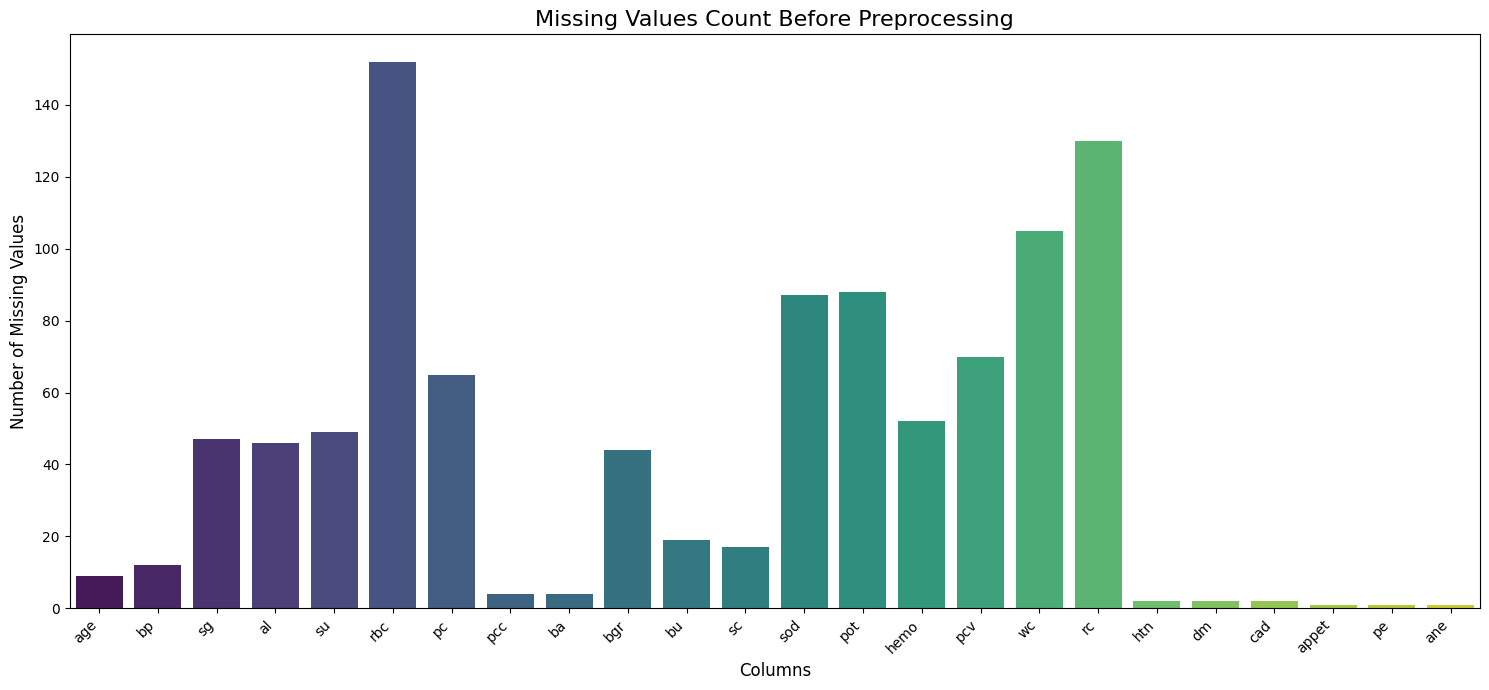

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sum of null values for each column and store it in a new variable.
missing_values = df.isnull().sum()

# Exclude columns that have zero missing values.
missing_values = missing_values[missing_values > 0]

# Check if there are any missing values to plot
if not missing_values.empty:
    # Create a bar plot
    plt.figure(figsize=(15, 7))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')

    # Set the title of the plot
    plt.title('Missing Values Count Before Preprocessing', fontsize=16)

    # Label the x-axis and y-axis
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)

    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')

    # Add legend (though for a single bar chart, it's often implicit or not needed)
    # If we wanted to distinguish types of missing values, a legend would be more useful.
    # For now, the colors distinguish bars, but a label for 'missing values' is not typically needed.
    # plt.legend(title='Missing Values', labels=['Count'])

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No missing values found in the DataFrame.")

**Reasoning**:
The previous code produced a FutureWarning from seaborn regarding the `palette` argument without `hue`. To address this, I will explicitly set `hue=missing_values.index` and `legend=False` in the `sns.barplot` function, as suggested by the warning, to ensure compatibility with future seaborn versions and maintain the desired visualization.



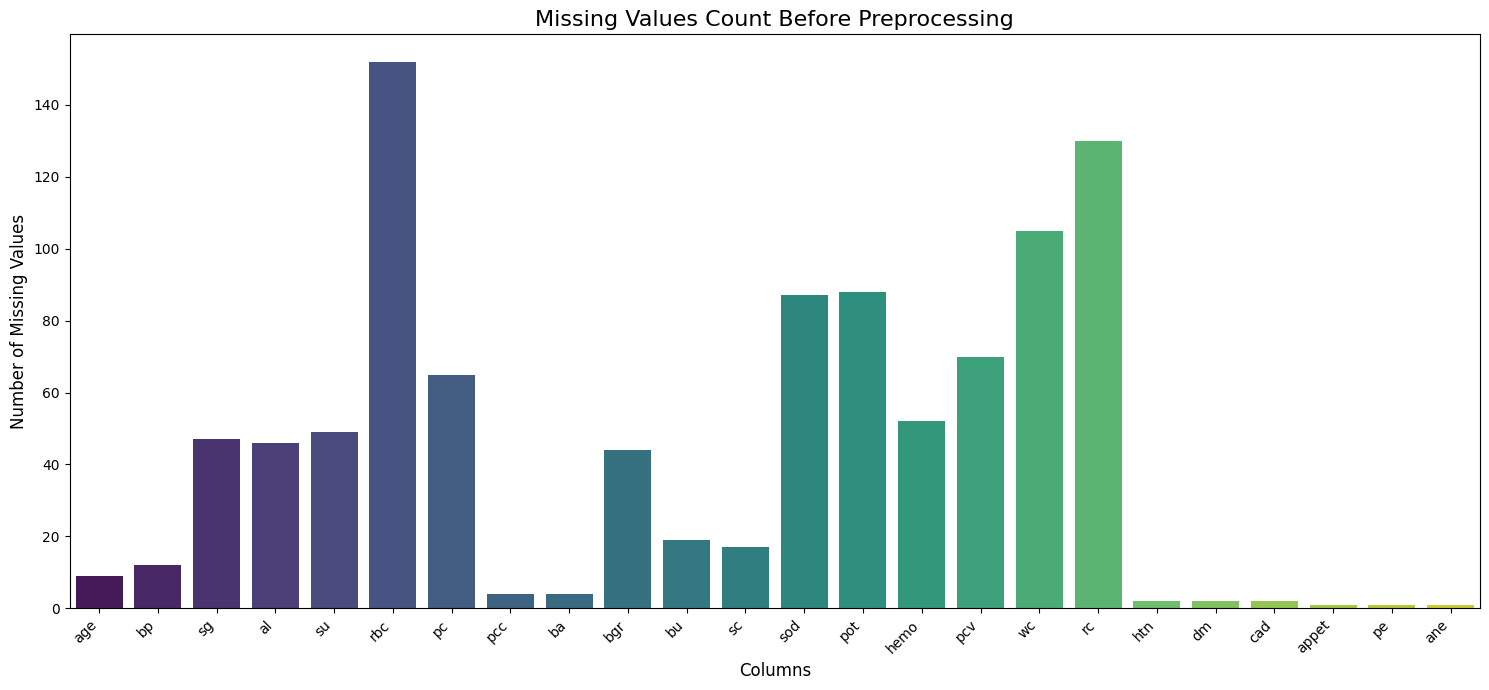

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sum of null values for each column and store it in a new variable.
missing_values = df.isnull().sum()

# Exclude columns that have zero missing values.
missing_values = missing_values[missing_values > 0]

# Check if there are any missing values to plot
if not missing_values.empty:
    # Create a bar plot
    plt.figure(figsize=(15, 7))
    sns.barplot(x=missing_values.index, y=missing_values.values, hue=missing_values.index, palette='viridis', legend=False)

    # Set the title of the plot
    plt.title('Missing Values Count Before Preprocessing', fontsize=16)

    # Label the x-axis and y-axis
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)

    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No missing values found in the DataFrame.")

## Handle Missing Values

### Subtask:
Implement a strategy to address the identified missing values. This will involve converting certain object-type columns to numeric, and then imputing missing values using appropriate methods (median for numerical, mode for categorical).


**Reasoning**:
First, I will convert the 'pcv', 'wc', and 'rc' columns from object to numeric type, as instructed. This involves inspecting their unique values, cleaning any non-numeric entries (like tabs or spaces) by replacing them with NaN, and then coercing the columns to a numeric data type.



In [6]:
import numpy as np

# Columns to convert to numeric
columns_to_convert = ['pcv', 'wc', 'rc']

for col in columns_to_convert:
    # Inspect unique values before conversion to find non-numeric entries
    print(f"Unique values in '{col}' before cleaning: {df[col].unique()}")

    # Replace non-numeric entries (like \t, \n, spaces) with NaN
    # First, convert to string type to use .str methods safely, then remove non-digit/non-decimal chars
    # and convert empty strings to NaN. Finally, convert to numeric, coercing errors.
    df[col] = df[col].astype(str).str.strip()
    # Replace specific non-numeric characters/strings that are not actual numbers
    # This part might need adjustment based on actual data inspection, for now, handle common non-numeric strings
    df[col] = df[col].replace({'\t': np.nan, ' ': np.nan, '': np.nan})

    # Convert to numeric, coercing errors will turn problematic values into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"Unique values in '{col}' after cleaning and conversion: {df[col].unique()}\n")

print("Data types after converting specified columns:")
df[columns_to_convert].info()

Unique values in 'pcv' before cleaning: ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']
Unique values in 'pcv' after cleaning and conversion: [44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]

Unique values in 'wc' before cleaning: ['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '

**Reasoning**:
Now that the 'pcv', 'wc', and 'rc' columns have been correctly converted to numeric types, I will proceed to separate the DataFrame into numerical and categorical columns. This will allow for appropriate imputation strategies for each data type: median for numerical columns and mode for categorical columns.



In [7]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute missing values in numerical columns with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute missing values in categorical columns with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple modes, take the first one
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing Values Count after Imputation:")
print(df.isnull().sum())

Imputed numerical column 'age' with median: 55.0
Imputed numerical column 'bp' with median: 80.0
Imputed numerical column 'sg' with median: 1.02
Imputed numerical column 'al' with median: 0.0
Imputed numerical column 'su' with median: 0.0
Imputed numerical column 'bgr' with median: 121.0
Imputed numerical column 'bu' with median: 42.0
Imputed numerical column 'sc' with median: 1.3
Imputed numerical column 'sod' with median: 138.0
Imputed numerical column 'pot' with median: 4.4
Imputed numerical column 'hemo' with median: 12.649999999999999
Imputed numerical column 'pcv' with median: 40.0
Imputed numerical column 'wc' with median: 8000.0
Imputed numerical column 'rc' with median: 4.8
Imputed categorical column 'rbc' with mode: normal
Imputed categorical column 'pc' with mode: normal
Imputed categorical column 'pcc' with mode: notpresent
Imputed categorical column 'ba' with mode: notpresent
Imputed categorical column 'htn' with mode: no
Imputed categorical column 'dm' with mode: no
Imput

/tmp/ipython-input-3945141445.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-3945141445.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

**Reasoning**:
The previous code block generated `FutureWarning` messages due to the use of `inplace=True` with `fillna()`. To address this and ensure compatibility with future pandas versions, I will modify the code to assign the result of `fillna()` back to the DataFrame column, which is the recommended practice.



In [8]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute missing values in numerical columns with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

# Impute missing values in categorical columns with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple modes, take the first one
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

print("\nMissing Values Count after Imputation:")
print(df.isnull().sum())


Missing Values Count after Imputation:
id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


## Visualize Missing Values (After Preprocessing)

### Subtask:
Generate a visualization, such as a bar chart or heatmap, to show the distribution and count of missing values after the preprocessing steps, demonstrating the impact of the handling strategy. Ensure to include a legend.


**Reasoning**:
To visualize the remaining missing values after preprocessing, I will calculate the sum of null values for each column and then generate a bar plot if any missing values still exist, otherwise, print a confirmation message.



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the sum of null values for each column and store it in a new variable.
missing_values_after_imputation = df.isnull().sum()

# Exclude columns that have zero missing values.
missing_values_after_imputation = missing_values_after_imputation[missing_values_after_imputation > 0]

# Check if there are any missing values to plot
if not missing_values_after_imputation.empty:
    # Create a bar plot
    plt.figure(figsize=(15, 7))
    sns.barplot(x=missing_values_after_imputation.index, y=missing_values_after_imputation.values, hue=missing_values_after_imputation.index, palette='viridis', legend=False)

    # Set the title of the plot
    plt.title('Missing Values Count After Preprocessing', fontsize=16)

    # Label the x-axis and y-axis
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)

    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("No missing values found in the DataFrame after imputation.")

No missing values found in the DataFrame after imputation.


## Final Task

### Subtask:
Summarize the data preprocessing steps taken, including the methods used to handle missing values, and discuss the visual changes observed before and after preprocessing.


## Summary:

### Q&A
The data preprocessing involved several steps to prepare the `kidney_disease.csv` dataset. Initially, an overview of the dataset revealed 400 entries across 26 columns, including 11 float64, 1 int64, and 14 object type columns. A significant number of missing values were identified, particularly in columns like `rbc` (152), `rc` (130), `wc` (105), `pot` (88), `sod` (87), `pcv` (70), and `pc` (65).

The handling of missing values involved two main phases:
1.  **Type Conversion and Cleaning**: The columns `pcv`, `wc`, and `rc` were initially identified as `object` type despite containing numerical information. These columns were cleaned by replacing non-numeric characters (e.g., `'\t?'`, `'\t6200'`) with `NaN` and then successfully converted to `float64` data type.
2.  **Imputation**:
    *   For **numerical columns** (including `age`, `bp`, `sg`, `al`, `su`, `bgr`, `bu`, `sc`, `sod`, `pot`, `hemo`, `pcv`, `wc`, `rc`), missing values were imputed using the **median** of their respective columns.
    *   For **categorical columns** (including `rbc`, `pc`, `pcc`, `ba`, `htn`, `dm`, `cad`, `appet`, `pe`, `ane`), missing values were imputed using the **mode** of their respective columns.

Visually, before preprocessing, a bar chart explicitly showed the number of missing values across various columns, highlighting the significant data gaps. After these preprocessing steps, a subsequent attempt to visualize missing values resulted in a message confirming "No missing values found in the DataFrame after imputation," indicating that all identified missing values were successfully handled and the dataset was fully cleaned.

### Data Analysis Key Findings
*   The initial dataset contained 400 entries and 26 columns, with a notable presence of missing values across many features.
*   Columns `rbc`, `rc`, `wc`, `pot`, `sod`, `pcv`, and `pc` exhibited the highest counts of missing values, with `rbc` having 152 missing entries and `rc` having 130.
*   Three critical columns (`pcv`, `wc`, `rc`) were initially of `object` data type and contained problematic non-numeric characters (e.g., `'\t?'`, `'\t6200'`) alongside numerical data, which were successfully cleaned and converted to `float64`.
*   All missing numerical values were imputed using the median of their respective columns, while all missing categorical values were imputed using the mode, resulting in a dataset with zero missing values.
*   The visualization of missing values before preprocessing clearly illustrated the extent of missing data, while the visualization after preprocessing confirmed the complete absence of any remaining missing values.

### Insights or Next Steps
*   The chosen imputation strategy (median for numerical, mode for categorical) is a robust approach for handling missing data, ensuring the dataset is clean and ready for further analysis or model training.
*   For future analysis, consider evaluating the impact of the imputation choices on model performance or feature distributions, especially for columns with a high percentage of missing values, and potentially explore more advanced imputation techniques if warranted by the domain or specific analytical goals.
